In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 9,
    "figure.figsize": (7.5, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Topology sweep ──
TOPO_DIR = os.path.join("..", "results", "topology_sweep")
topo_ts = pd.read_csv(os.path.join(TOPO_DIR, "timeseries_agg.csv"))
topo_sum = pd.read_csv(os.path.join(TOPO_DIR, "summary_table.csv"))
topo_runs = pd.read_csv(os.path.join(TOPO_DIR, "runs_summary.csv"))

# ── Seeding experiment ──
SEED_DIR = os.path.join("..", "results", "seeding_aid")
seed_ts = pd.read_csv(os.path.join(SEED_DIR, "timeseries_agg.csv"))
seed_sum = pd.read_csv(os.path.join(SEED_DIR, "summary_table.csv"))
seed_runs = pd.read_csv(os.path.join(SEED_DIR, "runs_summary.csv"))

TOPO_LABELS = {
    "er": "Erdős–Rényi (ER)",
    "ws": "Watts–Strogatz (WS)",
    "ba": "Barabási–Albert (BA)",
    "sbm": "Stochastic Block Model (SBM)",
}
TOPO_ORDER = ["er", "ws", "ba", "sbm"]
TOPO_COLORS = {"er": "#1f77b4", "ws": "#ff7f0e", "ba": "#2ca02c", "sbm": "#d62728"}

STRAT_LABELS = {
    "none": "No Aid",
    "random": "Random",
    "poorest_first": "Poorest First",
    "degree": "Degree (Hubs)",
    "betweenness": "Betweenness",
    "pagerank": "PageRank",
    "bridge_betweenness": "Bridge Betw.",
    "community_spread": "Comm. Spread",
    "community_clustered": "Comm. Clustered",
}
STRAT_ORDER = ["none", "random", "poorest_first", "degree", "betweenness",
               "pagerank", "bridge_betweenness", "community_spread", "community_clustered"]

print("Topology sweep:", topo_runs.shape[0], "runs,", topo_ts["t"].max() + 1, "timesteps")
print("Seeding experiment:", seed_runs.shape[0], "runs,", seed_ts["t"].max() + 1, "timesteps")

Topology sweep: 200 runs, 500 timesteps
Seeding experiment: 450 runs, 500 timesteps


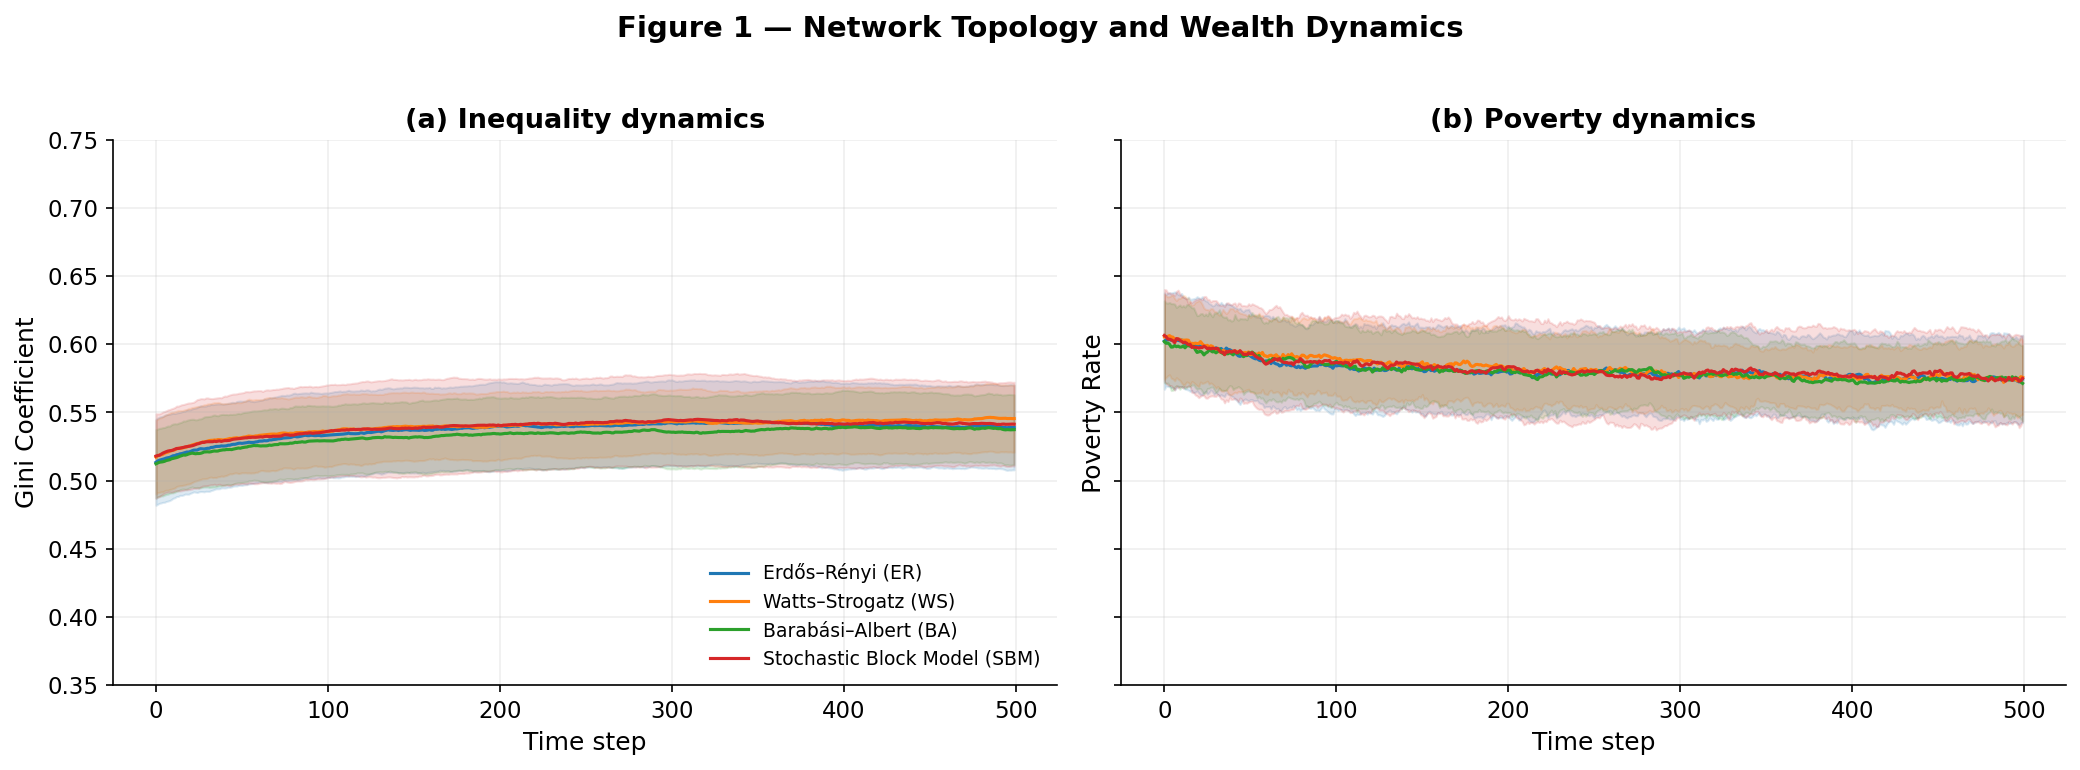

In [8]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 1: Gini and Poverty Over Time by Topology (2-panel)
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, metric, ylabel, title in zip(
    axes,
    ["gini_mean", "pov_mean"],
    ["Gini Coefficient", "Poverty Rate"],
    ["(a) Inequality dynamics", "(b) Poverty dynamics"],
):
    for g in TOPO_ORDER:
        sub = topo_ts[topo_ts["graph_type"] == g].sort_values("t")
        x = sub["t"].values
        y = sub[metric].values
        s = sub[metric.replace("mean", "std")].values
        ax.plot(x, y, label=TOPO_LABELS[g], color=TOPO_COLORS[g], linewidth=1.5)
        ax.fill_between(x, y - s, y + s, alpha=0.15, color=TOPO_COLORS[g])
    ax.set_xlabel("Time step")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0.35, 0.75)
    ax.grid(True, alpha=0.2)

axes[0].legend(frameon=False, loc="lower right")
fig.suptitle("Figure 1 — Network Topology and Wealth Dynamics", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(TOPO_DIR, "fig1_dynamics_by_topology.png"), dpi=300, bbox_inches="tight")
plt.show()

/var/folders/1n/j_163jy976j9ry5hl88xm2vr0000gv/T/ipykernel_520/2681988567.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data_esc, labels=[TOPO_LABELS[g] for g in TOPO_ORDER],
/var/folders/1n/j_163jy976j9ry5hl88xm2vr0000gv/T/ipykernel_520/2681988567.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_rank, labels=[TOPO_LABELS[g] for g in TOPO_ORDER],


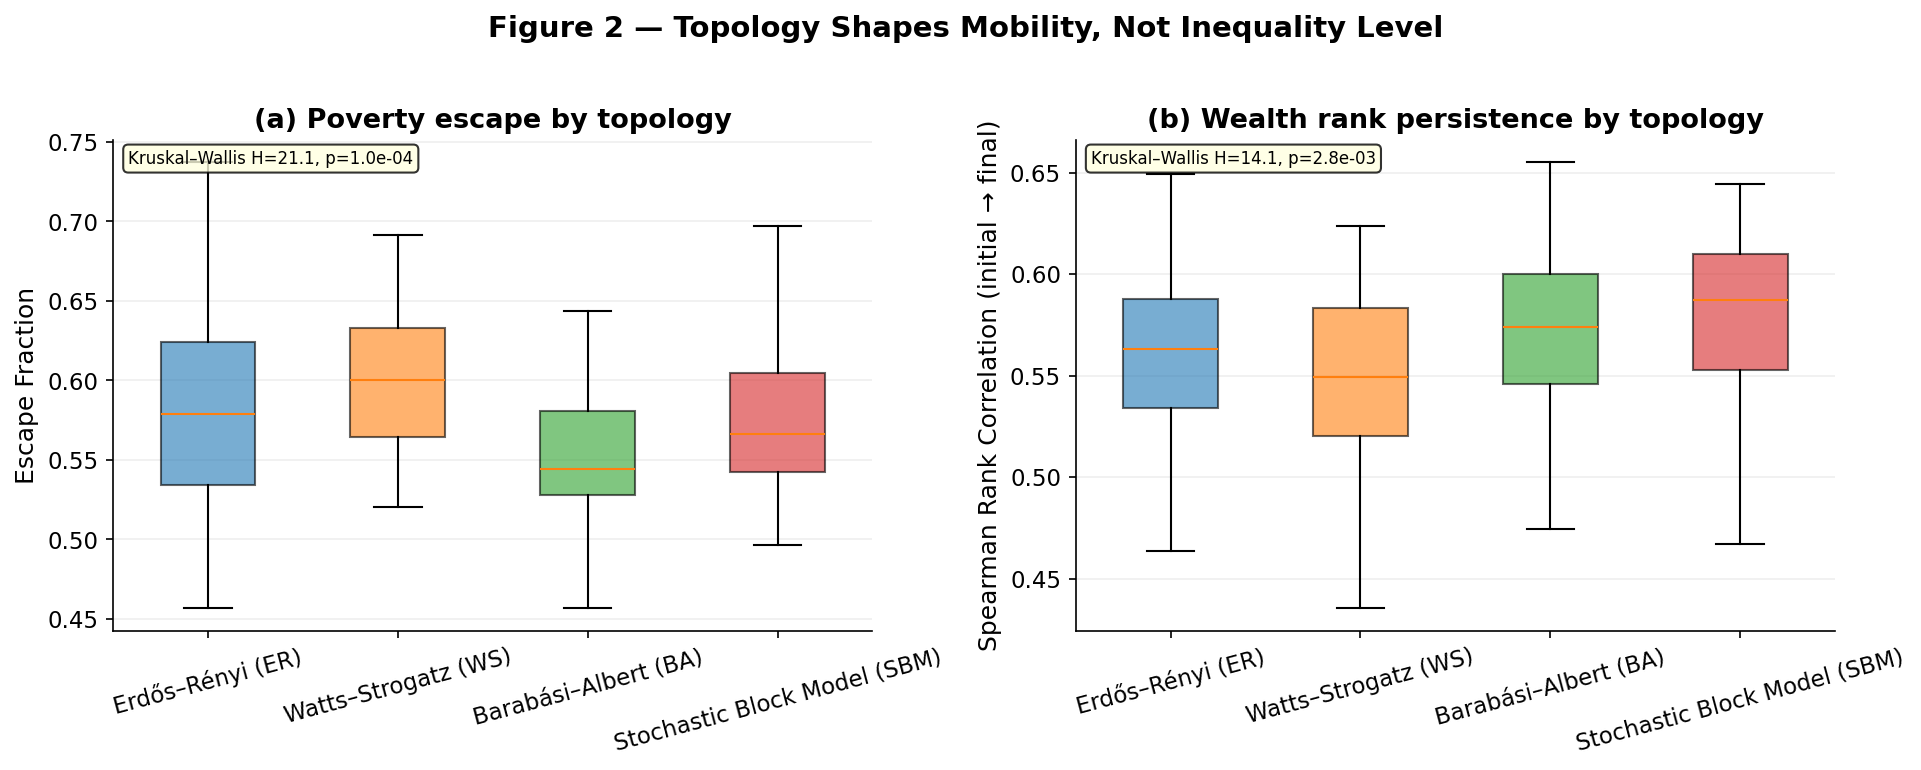

In [9]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 2: Escape Fraction & Rank Persistence by Topology
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel (a): Escape fraction box plot
data_esc = [topo_runs[topo_runs["graph_type"] == g]["escape_fraction"] for g in TOPO_ORDER]
bp1 = axes[0].boxplot(data_esc, labels=[TOPO_LABELS[g] for g in TOPO_ORDER],
                       patch_artist=True, widths=0.5, showfliers=False)
for patch, g in zip(bp1["boxes"], TOPO_ORDER):
    patch.set_facecolor(TOPO_COLORS[g])
    patch.set_alpha(0.6)
axes[0].set_ylabel("Escape Fraction")
axes[0].set_title("(a) Poverty escape by topology", fontweight="bold")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(True, axis="y", alpha=0.2)

# Kruskal-Wallis annotation
h, p = stats.kruskal(*data_esc)
axes[0].text(0.02, 0.98, f"Kruskal–Wallis H={h:.1f}, p={p:.1e}",
             transform=axes[0].transAxes, fontsize=8, va="top",
             bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))

# Panel (b): Rank persistence (Spearman)
data_rank = [topo_runs[topo_runs["graph_type"] == g]["spearman_rank_corr"] for g in TOPO_ORDER]
bp2 = axes[1].boxplot(data_rank, labels=[TOPO_LABELS[g] for g in TOPO_ORDER],
                       patch_artist=True, widths=0.5, showfliers=False)
for patch, g in zip(bp2["boxes"], TOPO_ORDER):
    patch.set_facecolor(TOPO_COLORS[g])
    patch.set_alpha(0.6)
axes[1].set_ylabel("Spearman Rank Correlation (initial → final)")
axes[1].set_title("(b) Wealth rank persistence by topology", fontweight="bold")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(True, axis="y", alpha=0.2)

h2, p2 = stats.kruskal(*data_rank)
axes[1].text(0.02, 0.98, f"Kruskal–Wallis H={h2:.1f}, p={p2:.1e}",
             transform=axes[1].transAxes, fontsize=8, va="top",
             bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8))

fig.suptitle("Figure 2 — Topology Shapes Mobility, Not Inequality Level",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(TOPO_DIR, "fig2_escape_rank_topology.png"), dpi=300, bbox_inches="tight")
plt.show()

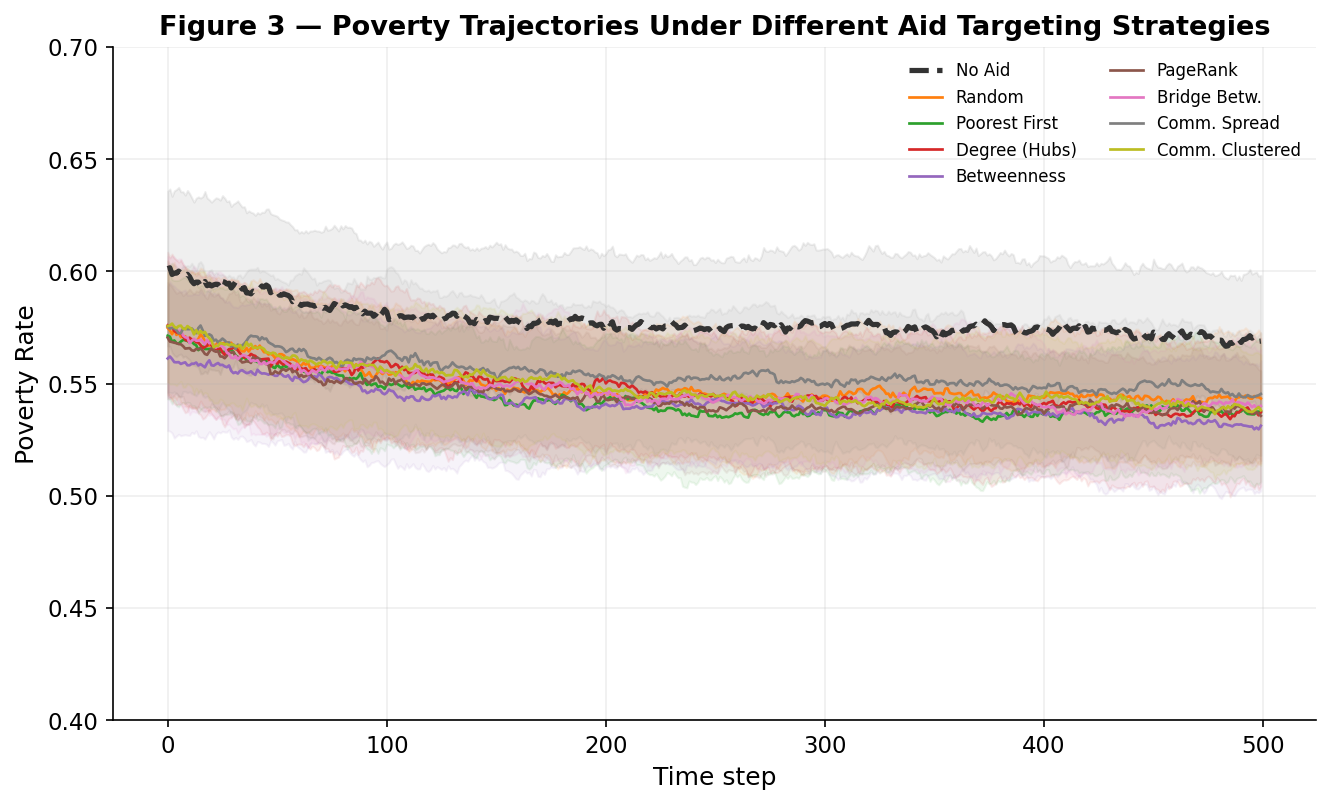

In [10]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 3: Poverty Over Time by Targeting Strategy
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(9, 5.5))

cmap = plt.cm.tab10
strat_colors = {s: cmap(i) for i, s in enumerate(STRAT_ORDER)}
strat_colors["none"] = "#333333"

for s in STRAT_ORDER:
    sub = seed_ts[seed_ts["strategy"] == s].sort_values("t")
    if sub.empty:
        continue
    x = sub["t"].values
    y = sub["pov_mean"].values
    sd = sub["pov_std"].values
    lw = 2.5 if s == "none" else 1.3
    ls = "--" if s == "none" else "-"
    ax.plot(x, y, label=STRAT_LABELS.get(s, s), color=strat_colors[s], linewidth=lw, linestyle=ls)
    ax.fill_between(x, y - sd, y + sd, alpha=0.08, color=strat_colors[s])

ax.set_xlabel("Time step")
ax.set_ylabel("Poverty Rate")
ax.set_title("Figure 3 — Poverty Trajectories Under Different Aid Targeting Strategies",
             fontweight="bold")
ax.set_ylim(0.40, 0.70)
ax.grid(True, alpha=0.2)
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(SEED_DIR, "fig3_poverty_by_strategy.png"), dpi=300, bbox_inches="tight")
plt.show()

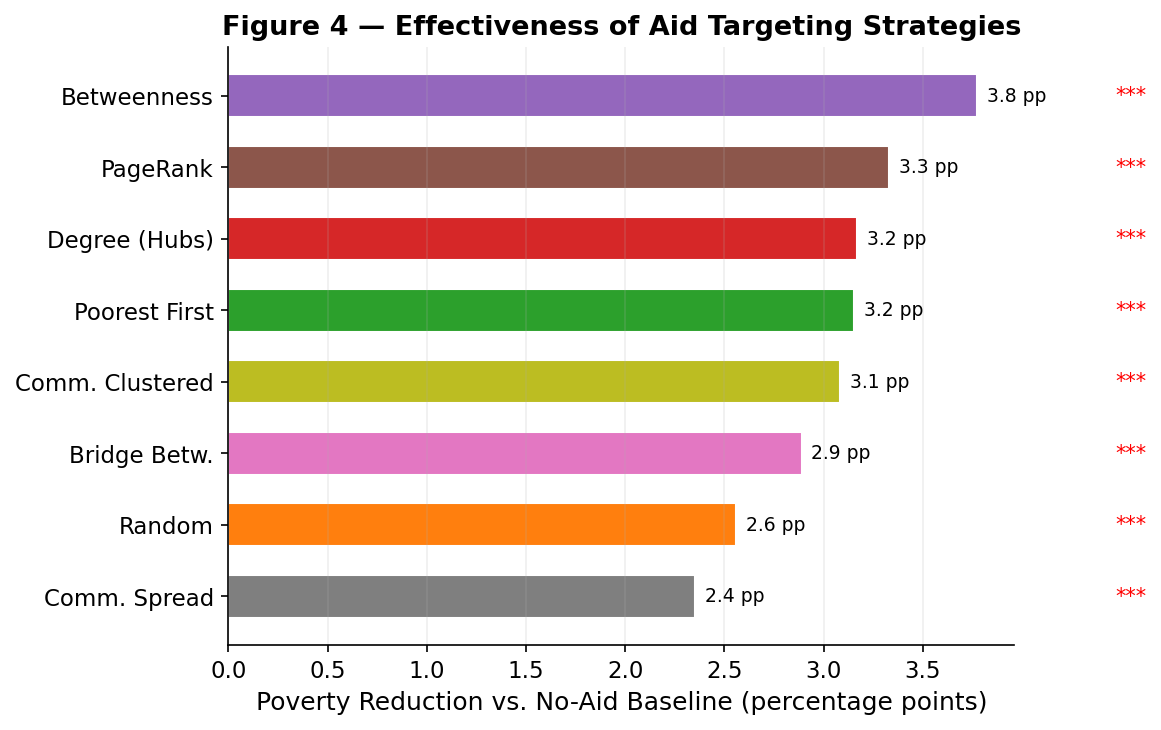

In [11]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 4: Poverty Reduction vs. Baseline (none) — bar chart
# ═══════════════════════════════════════════════════════════════

baseline_pov = seed_sum.loc[seed_sum["strategy"] == "none", "poverty_final_mean"].values[0]
df_bar = seed_sum[seed_sum["strategy"] != "none"].copy()
df_bar["pov_reduction_pp"] = (baseline_pov - df_bar["poverty_final_mean"]) * 100
df_bar["label"] = df_bar["strategy"].map(STRAT_LABELS)

# Sort by reduction
df_bar = df_bar.sort_values("pov_reduction_pp", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [strat_colors.get(s, "#888") for s in df_bar["strategy"]]
bars = ax.barh(df_bar["label"], df_bar["pov_reduction_pp"], color=colors, edgecolor="white", height=0.6)
ax.set_xlabel("Poverty Reduction vs. No-Aid Baseline (percentage points)")
ax.set_title("Figure 4 — Effectiveness of Aid Targeting Strategies", fontweight="bold")
ax.grid(True, axis="x", alpha=0.2)

# Add value labels
for bar, val in zip(bars, df_bar["pov_reduction_pp"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1f} pp", va="center", fontsize=9)

# Statistical significance markers from Mann-Whitney vs none
none_runs = seed_runs[seed_runs["strategy"] == "none"]["poverty_final"]
for i, (_, row) in enumerate(df_bar.iterrows()):
    strat_runs = seed_runs[seed_runs["strategy"] == row["strategy"]]["poverty_final"]
    _, p = stats.mannwhitneyu(strat_runs, none_runs, alternative="less")
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    if sig:
        ax.text(bar.get_width() + 0.7, bars[i].get_y() + bars[i].get_height()/2,
                sig, va="center", fontsize=10, color="red")

fig.tight_layout()
fig.savefig(os.path.join(SEED_DIR, "fig4_poverty_reduction_bar.png"), dpi=300, bbox_inches="tight")
plt.show()

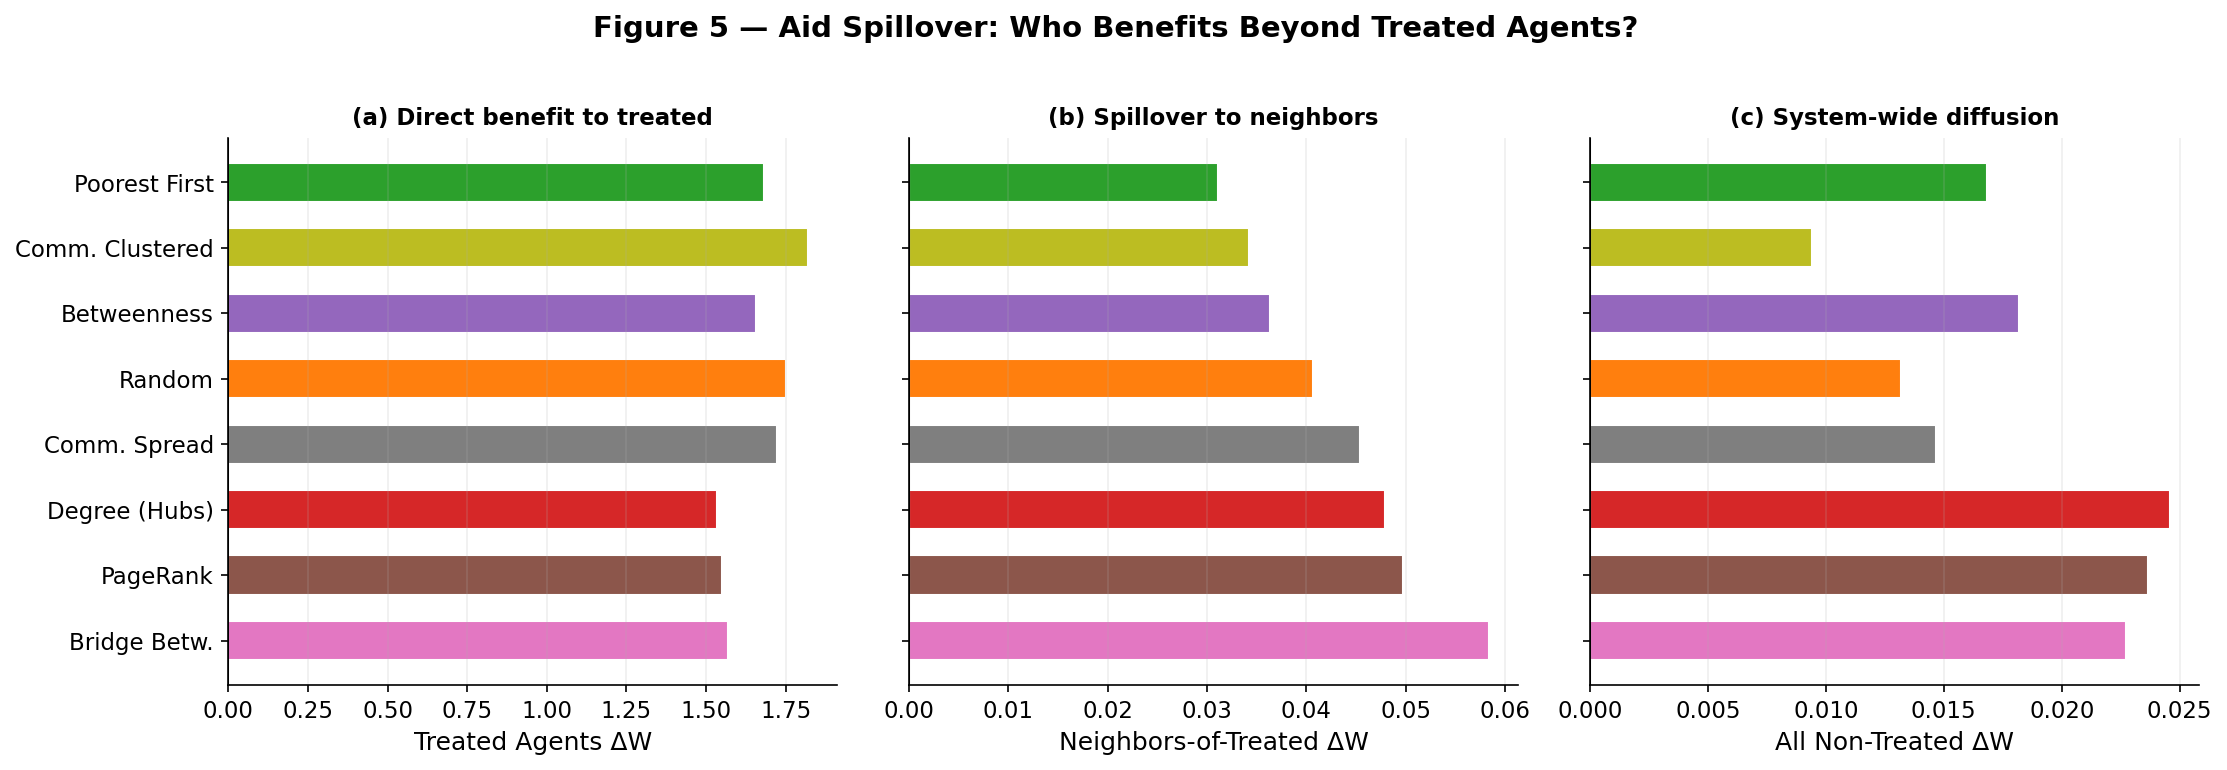

In [12]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 5: Spillover Analysis — Treated vs Neighbor vs Non-treated
# ═══════════════════════════════════════════════════════════════

df_spill = seed_sum[seed_sum["strategy"] != "none"].copy()
df_spill["label"] = df_spill["strategy"].map(STRAT_LABELS)

# Sort by neighbor spillover
df_spill = df_spill.sort_values("neighbor_mean_dW_mean", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

metrics = [
    ("treated_mean_dW_mean", "Treated Agents ΔW", "(a) Direct benefit to treated"),
    ("neighbor_mean_dW_mean", "Neighbors-of-Treated ΔW", "(b) Spillover to neighbors"),
    ("non_treated_mean_dW_mean", "All Non-Treated ΔW", "(c) System-wide diffusion"),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    bars = ax.barh(df_spill["label"], df_spill[col],
                   color=[strat_colors.get(s, "#888") for s in df_spill["strategy"]],
                   edgecolor="white", height=0.6)
    ax.set_xlabel(ylabel)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.grid(True, axis="x", alpha=0.2)
    ax.axvline(0, color="black", linewidth=0.5)

fig.suptitle("Figure 5 — Aid Spillover: Who Benefits Beyond Treated Agents?",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SEED_DIR, "fig5_spillover_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════════
# TABLE 1: Topology Sweep Summary
# ═══════════════════════════════════════════════════════════════

topo_table = topo_runs.groupby("graph_type").agg(
    Gini=("gini_final", lambda x: f"{x.mean():.3f} ± {x.std():.3f}"),
    Poverty=("poverty_final", lambda x: f"{x.mean():.3f} ± {x.std():.3f}"),
    Escape=("escape_fraction", lambda x: f"{x.mean():.3f} ± {x.std():.3f}"),
    EscTime=("escape_time_mean", lambda x: f"{x.mean():.1f} ± {x.std():.1f}"),
    RankCorr=("spearman_rank_corr", lambda x: f"{x.mean():.3f} ± {x.std():.3f}"),
).reindex(TOPO_ORDER)

topo_table.index = topo_table.index.map(TOPO_LABELS)
topo_table.columns = ["Gini (final)", "Poverty (final)", "Escape Fraction",
                        "Escape Time", "Rank ρ (Spearman)"]
print("Table 1: Topology Sweep Results (mean ± std, n=50 runs each)\n")
topo_table

Table 1: Topology Sweep Results (mean ± std, n=50 runs each)



,Gini (final),Poverty (final),Escape Fraction,Escape Time,Rank ρ (Spearman)
graph_type,,,,,
Erdős–Rényi (ER),0.539 ± 0.031,0.575 ± 0.032,0.582 ± 0.061,171.9 ± 16.2,0.558 ± 0.047
Watts–Strogatz (WS),0.546 ± 0.025,0.576 ± 0.027,0.599 ± 0.048,173.1 ± 17.7,0.547 ± 0.046
Barabási–Albert (BA),0.537 ± 0.026,0.571 ± 0.028,0.549 ± 0.046,167.4 ± 14.5,0.571 ± 0.050
Stochastic Block Model (SBM),0.541 ± 0.031,0.575 ± 0.031,0.576 ± 0.051,170.2 ± 14.0,0.577 ± 0.046


In [14]:
# ═══════════════════════════════════════════════════════════════
# TABLE 2: Seeding Experiment Summary
# ═══════════════════════════════════════════════════════════════

seed_table = seed_runs.groupby("strategy").agg(
    Poverty=("poverty_final", lambda x: f"{x.mean():.3f} ± {x.std():.3f}"),
    Gini=("gini_final", lambda x: f"{x.mean():.3f} ± {x.std():.3f}"),
    Escape=("escape_fraction", lambda x: f"{x.mean():.3f} ± {x.std():.3f}"),
    TreatedDW=("treated_mean_dW", lambda x: f"{x.mean():+.3f}" if not x.isna().all() else "—"),
    NeighborDW=("neighbor_mean_dW", lambda x: f"{x.mean():+.4f}" if not x.isna().all() else "—"),
    NonTrtDW=("non_treated_mean_dW", lambda x: f"{x.mean():+.4f}"),
).reindex([s for s in STRAT_ORDER if s in seed_runs["strategy"].unique()])

seed_table.index = seed_table.index.map(STRAT_LABELS)
seed_table.columns = ["Poverty (final)", "Gini (final)", "Escape Fraction",
                       "Treated ΔW", "Neighbor ΔW", "Non-treated ΔW"]
print("Table 2: Aid Targeting Results (mean ± std, n=50 runs each)\n")
seed_table

Table 2: Aid Targeting Results (mean ± std, n=50 runs each)



,Poverty (final),Gini (final),Escape Fraction,Treated ΔW,Neighbor ΔW,Non-treated ΔW
strategy,,,,,,
No Aid,0.569 ± 0.029,0.541 ± 0.029,0.576 ± 0.050,—,—,+0.0000
Random,0.543 ± 0.029,0.539 ± 0.028,0.595 ± 0.053,+1.750,+0.0407,+0.0132
Poorest First,0.537 ± 0.031,0.533 ± 0.025,0.589 ± 0.051,+1.681,+0.0312,+0.0168
Degree (Hubs),0.537 ± 0.033,0.536 ± 0.031,0.583 ± 0.052,+1.534,+0.0479,+0.0246
Betweenness,0.531 ± 0.029,0.524 ± 0.028,0.582 ± 0.047,+1.656,+0.0364,+0.0182
PageRank,0.536 ± 0.020,0.532 ± 0.021,0.578 ± 0.049,+1.552,+0.0498,+0.0237
Bridge Betw.,0.540 ± 0.025,0.534 ± 0.024,0.584 ± 0.045,+1.570,+0.0584,+0.0227
Comm. Spread,0.545 ± 0.027,0.548 ± 0.027,0.585 ± 0.061,+1.722,+0.0455,+0.0147
Comm. Clustered,0.538 ± 0.025,0.537 ± 0.025,0.589 ± 0.044,+1.821,+0.0342,+0.0094


/var/folders/1n/j_163jy976j9ry5hl88xm2vr0000gv/T/ipykernel_520/905909375.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_pov, labels=[STRAT_LABELS[s] for s in strat_present],
/var/folders/1n/j_163jy976j9ry5hl88xm2vr0000gv/T/ipykernel_520/905909375.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_esc, labels=[STRAT_LABELS[s] for s in strat_present],


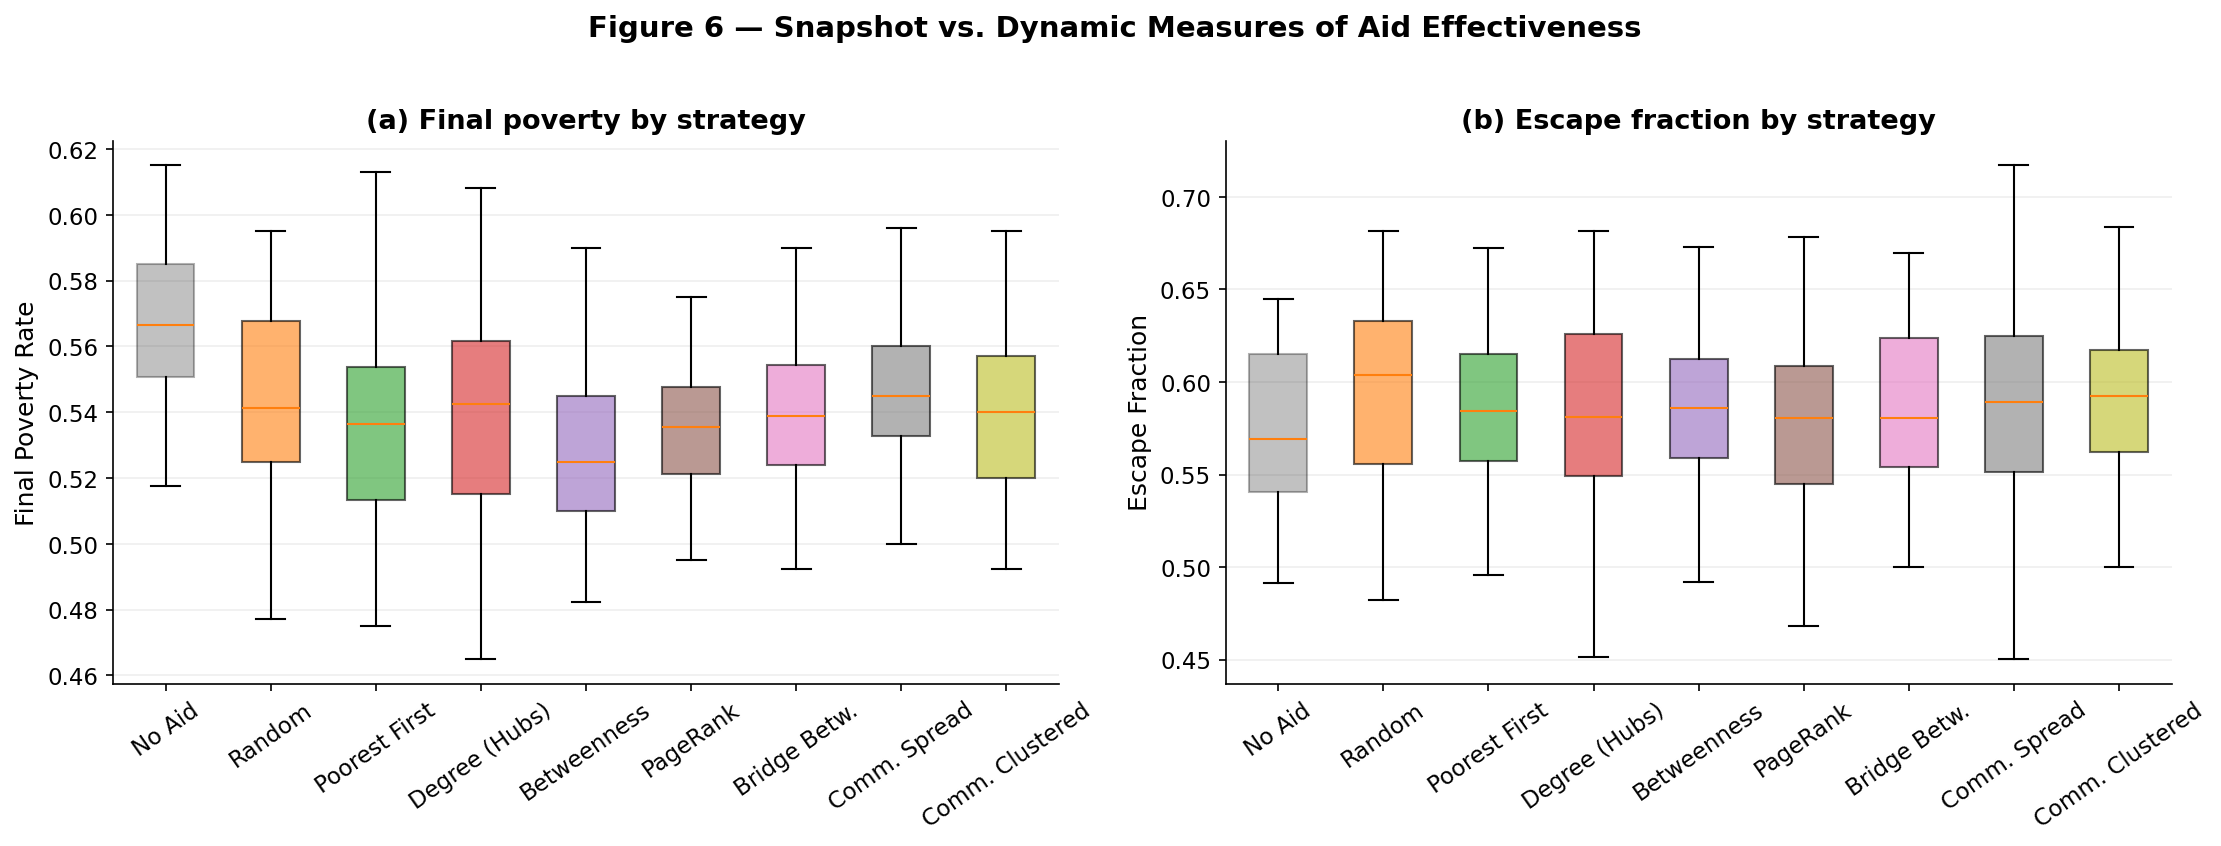

In [15]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 6: Escape Fraction by Strategy (box plot with baseline)
# ═══════════════════════════════════════════════════════════════

strat_present = [s for s in STRAT_ORDER if s in seed_runs["strategy"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Poverty final
data_pov = [seed_runs[seed_runs["strategy"] == s]["poverty_final"] for s in strat_present]
bp = axes[0].boxplot(data_pov, labels=[STRAT_LABELS[s] for s in strat_present],
                     patch_artist=True, widths=0.55, showfliers=False)
for patch, s in zip(bp["boxes"], strat_present):
    patch.set_facecolor(strat_colors.get(s, "#888"))
    patch.set_alpha(0.6 if s != "none" else 0.3)
axes[0].set_ylabel("Final Poverty Rate")
axes[0].set_title("(a) Final poverty by strategy", fontweight="bold")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(True, axis="y", alpha=0.2)

# (b) Escape fraction
data_esc = [seed_runs[seed_runs["strategy"] == s]["escape_fraction"] for s in strat_present]
bp2 = axes[1].boxplot(data_esc, labels=[STRAT_LABELS[s] for s in strat_present],
                      patch_artist=True, widths=0.55, showfliers=False)
for patch, s in zip(bp2["boxes"], strat_present):
    patch.set_facecolor(strat_colors.get(s, "#888"))
    patch.set_alpha(0.6 if s != "none" else 0.3)
axes[1].set_ylabel("Escape Fraction")
axes[1].set_title("(b) Escape fraction by strategy", fontweight="bold")
axes[1].tick_params(axis="x", rotation=35)
axes[1].grid(True, axis="y", alpha=0.2)

fig.suptitle("Figure 6 — Snapshot vs. Dynamic Measures of Aid Effectiveness",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SEED_DIR, "fig6_boxplots_strategy.png"), dpi=300, bbox_inches="tight")
plt.show()

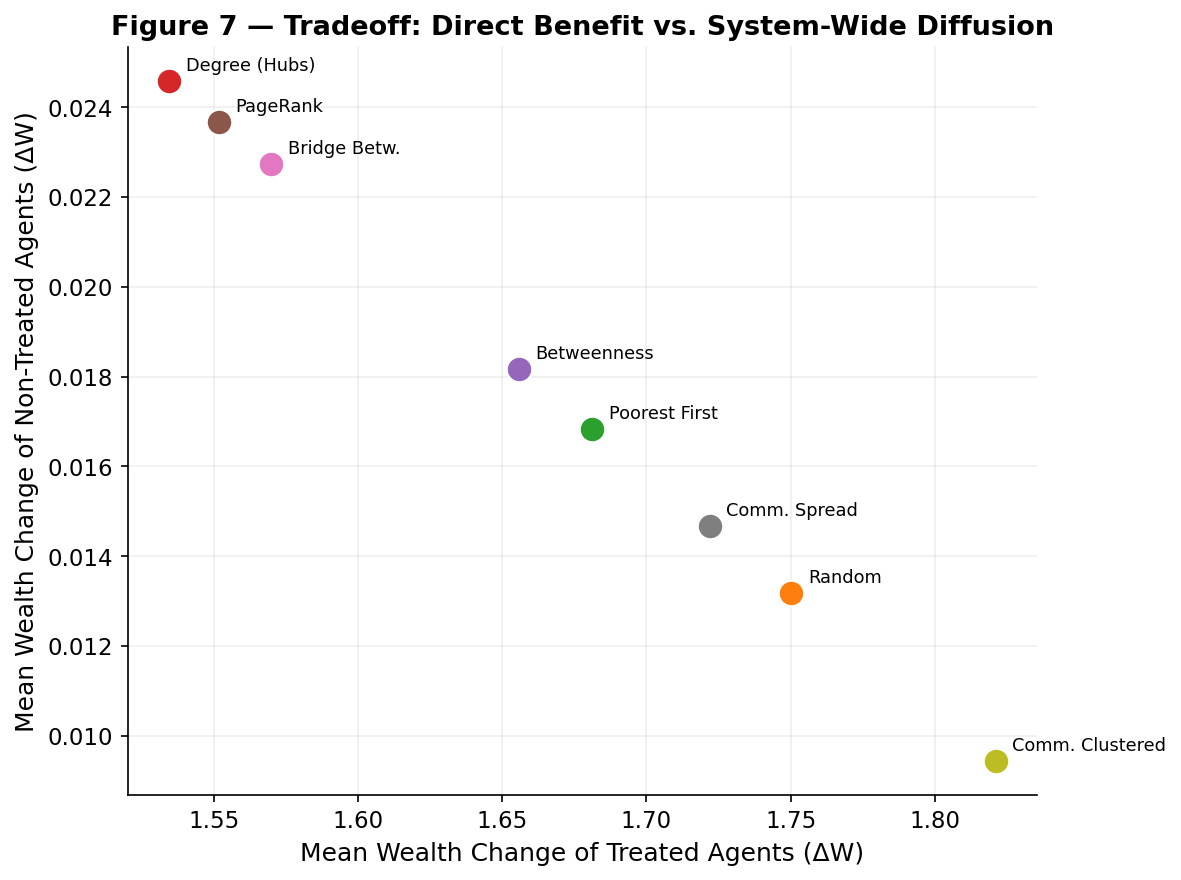

In [16]:
# ═══════════════════════════════════════════════════════════════
# FIGURE 7: Spillover Tradeoff — Direct Retention vs Network Diffusion
# ═══════════════════════════════════════════════════════════════

df_trade = seed_sum[seed_sum["strategy"] != "none"].copy()
df_trade["label"] = df_trade["strategy"].map(STRAT_LABELS)

fig, ax = plt.subplots(figsize=(8, 6))

for _, row in df_trade.iterrows():
    c = strat_colors.get(row["strategy"], "#888")
    ax.scatter(row["treated_mean_dW_mean"], row["non_treated_mean_dW_mean"],
               s=150, color=c, edgecolor="white", linewidth=1, zorder=3)
    ax.annotate(row["label"], (row["treated_mean_dW_mean"], row["non_treated_mean_dW_mean"]),
                textcoords="offset points", xytext=(8, 5), fontsize=8.5)

ax.set_xlabel("Mean Wealth Change of Treated Agents (ΔW)")
ax.set_ylabel("Mean Wealth Change of Non-Treated Agents (ΔW)")
ax.set_title("Figure 7 — Tradeoff: Direct Benefit vs. System-Wide Diffusion",
             fontweight="bold")
ax.grid(True, alpha=0.2)
fig.tight_layout()
fig.savefig(os.path.join(SEED_DIR, "fig7_tradeoff_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()